# Exercise 7: Transformer for Neutrino Interaction Reconstruction

In this exercise, we implement a Transformer to reconstruct the position of the neutrino interaction from the measured Cherenkov light.



In [4]:
!unzip -o "IceCube 2D Dataset.zip"
!pip install awkward


Archive:  IceCube 2D Dataset.zip
   creating: IceCube 2D Dataset/
  inflating: IceCube 2D Dataset/test.pq  
  inflating: IceCube 2D Dataset/train.pq  
  inflating: IceCube 2D Dataset/val.pq  


In [5]:
import os
import sys
import time
import copy
import math
import numpy as np
import matplotlib.pyplot as plt
import awkward

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence


## 1. Dataloading & Normalization


In [6]:
def collate_fn_transformer(batch):
    data_list = []
    labels = []
    lengths=[]

    for b in batch:
        tensordata = torch.from_numpy(b["data"].to_numpy()).T
        tensordata = tensordata.to(dtype=torch.float32)

        lengths.append(tensordata.shape[0])
        data_list.append(tensordata)
        labels.append(torch.Tensor([b["xpos"], b["ypos"]]).unsqueeze(0))

    labels = torch.cat(labels, dim=0)
    data_vec=torch.cat(data_list)
    return [data_vec, lengths], labels

DATA_PATH = "IceCube 2D Dataset/"
train_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = awkward.from_parquet(os.path.join(DATA_PATH, "test.pq"))

def normalize_dataset(dataset, stats=None):
    times = dataset["data"][:, 0:1, :]
    x = dataset["data"][:, 1:2, :]
    y = dataset["data"][:, 2:3, :]

    if stats is None:
        flat_times = awkward.flatten(times, axis=2)
        flat_x = awkward.flatten(x, axis=2)
        flat_y = awkward.flatten(y, axis=2)

        stats = {
            "time_mean": np.mean(flat_times), "time_std": np.std(flat_times),
            "x_mean": np.mean(flat_x), "x_std": np.std(flat_x),
            "y_mean": np.mean(flat_y), "y_std": np.std(flat_y),
            "xpos_mean": np.mean(dataset["xpos"]), "xpos_std": np.std(dataset["xpos"]),
            "ypos_mean": np.mean(dataset["ypos"]), "ypos_std": np.std(dataset["ypos"])
        }

    norm_times = (times - stats["time_mean"]) / stats["time_std"]
    norm_x = (x - stats["x_mean"]) / stats["x_std"]
    norm_y = (y - stats["y_mean"]) / stats["y_std"]

    dataset["data"] = awkward.concatenate([norm_times, norm_x, norm_y], axis=1)
    dataset["xpos"] = (dataset["xpos"] - stats["xpos_mean"]) / stats["xpos_std"]
    dataset["ypos"] = (dataset["ypos"] - stats["ypos_mean"]) / stats["ypos_std"]

    return dataset, stats

train_dataset, train_stats = normalize_dataset(train_dataset)
val_dataset, _ = normalize_dataset(val_dataset, train_stats)
test_dataset, _ = normalize_dataset(test_dataset, train_stats)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_transformer)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_transformer)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_transformer)


## 2. TransformerEncoder & PositionalEncoding Definition


In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, :x.size(1)]
        return x


# positional encodeing here usually not necessary because our data set is not structured

class TransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim=3,
        d_model=64,
        nhead=4,
        num_layers=3,
        output_dim=2,
        dim_feedforward=256,
        dropout=0.05
    ):
        super().__init__()

        self.input_embedding = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            activation="relu",
            batch_first=True,
            norm_first=True,
            dropout=dropout
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, output_dim)

    def forward(self, data) -> torch.Tensor:
        src, lengths = data

        # 1) embed
        embedded = self.input_embedding(src)

        # 2) split
        parts = embedded.split(lengths, dim=0)

        # 3) pad
        padded = pad_sequence(parts, batch_first=True)
        batch_size, max_len, _ = padded.shape

        # 3.5) Positional Encoding
        padded = self.pos_encoder(padded)

        # 4) mask
        mask = torch.zeros(batch_size, max_len, dtype=torch.bool).to(device=padded.device)
        for i, L in enumerate(lengths):
            mask[i, L:] = True

        # 5) call transformer
        enc_out = self.encoder(padded, src_key_padding_mask=mask)

        # 6) pool
        valid_mask = ~mask
        summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1)
        pooled = summed / torch.LongTensor(lengths)[:,None].to(enc_out)

        # 7) final output
        out = self.output_proj(pooled)
        return out


## 3. Training Loop


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = TransformerEncoder(d_model=64, nhead=4, num_layers=3, dropout=0.05).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
patience = 5

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    start_time = time.time()

    # Train
    model.train()
    total_train_loss = 0.0
    for batch_data, batch_labels in train_loader:
        src_vec, lengths = batch_data
        src_vec = src_vec.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        preds = model([src_vec, lengths])
        loss = criterion(preds, batch_labels)
        loss.backward()
        optimizer.step()

        # Multiply by batch_size to get total loss
        total_train_loss += loss.item() * len(lengths)

    avg_train_loss = total_train_loss / len(train_dataset)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch_data, batch_labels in val_loader:
            src_vec, lengths = batch_data
            src_vec = src_vec.to(device)
            batch_labels = batch_labels.to(device)

            preds = model([src_vec, lengths])
            loss = criterion(preds, batch_labels)
            total_val_loss += loss.item() * len(lengths)

    avg_val_loss = total_val_loss / len(val_dataset)
    val_losses.append(avg_val_loss)

    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_time:.2f}s")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)


Using device: cuda


/tmp/ipykernel_649/3164514304.py:45: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Epoch [1/20] Train Loss: 0.2837 | Val Loss: 0.1153 | Time: 14.97s
Epoch [2/20] Train Loss: 0.0951 | Val Loss: 0.0952 | Time: 16.66s
Epoch [3/20] Train Loss: 0.0810 | Val Loss: 0.0896 | Time: 14.09s
Epoch [4/20] Train Loss: 0.0780 | Val Loss: 0.0835 | Time: 13.53s
Epoch [5/20] Train Loss: 0.0754 | Val Loss: 0.0896 | Time: 15.23s
Epoch [6/20] Train Loss: 0.0730 | Val Loss: 0.0785 | Time: 13.71s
Epoch [7/20] Train Loss: 0.0686 | Val Loss: 0.0813 | Time: 13.63s
Epoch [8/20] Train Loss: 0.0662 | Val Loss: 0.0766 | Time: 13.55s
Epoch [9/20] Train Loss: 0.0643 | Val Loss: 0.0796 | Time: 13.51s
Epoch [10/20] Train Loss: 0.0624 | Val Loss: 0.0761 | Time: 13.86s
Epoch [11/20] Train Loss: 0.0616 | Val Loss: 0.0814 | Time: 13.83s
Epoch [12/20] Train Loss: 0.0624 | Val Loss: 0.0760 | Time: 13.64s
Epoch [13/20] Train Loss: 0.0588 | Val Loss: 0.0847 | Time: 13.45s
Epoch [14/20] Train Loss: 0.0652 | Val Loss: 0.0734 | Time: 13.47s
Epoch [15/20] Train Loss: 0.0559 | Val Loss: 0.0774 | Time: 13.47s
Epoc

## 4. Evaluation and Visualization


Test MSE: 3.3832
Mean Resolution (Euclidean Distance): 1.2964


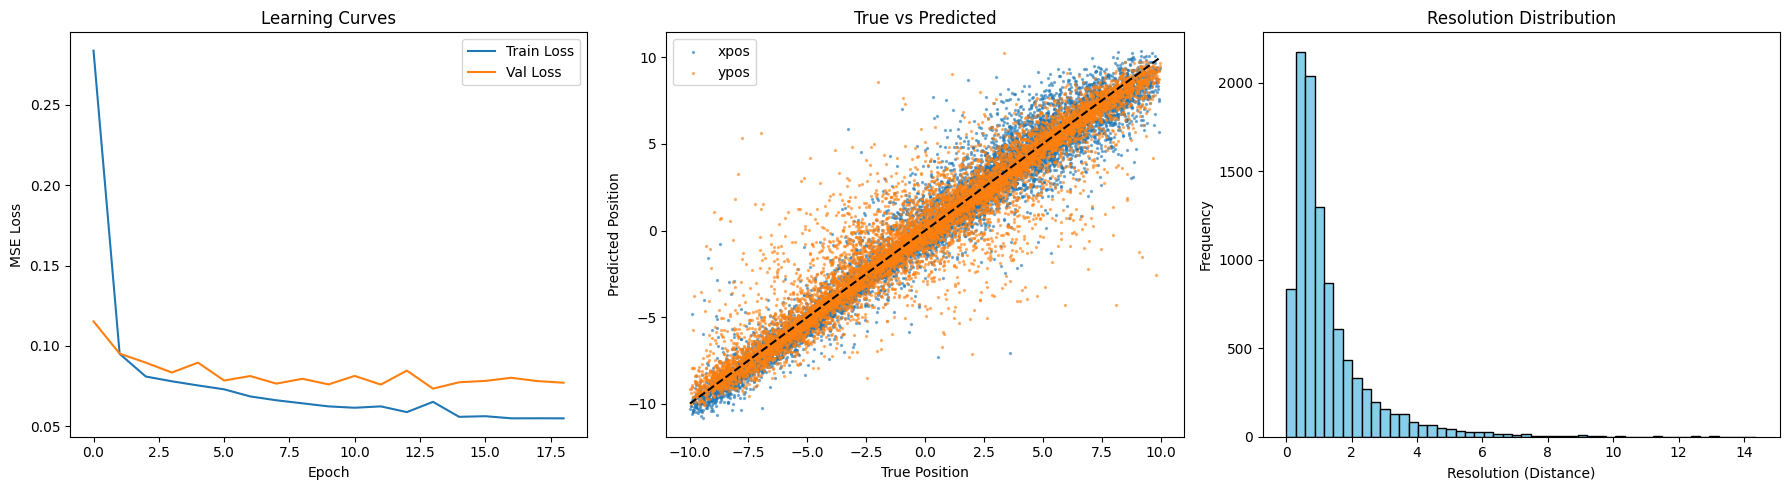

In [9]:
model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for batch_data, batch_labels in test_loader:
        src_vec, lengths = batch_data
        src_vec = src_vec.to(device)
        preds = model([src_vec, lengths])

        all_preds.append(preds.cpu().numpy())
        all_trues.append(batch_labels.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_trues = np.concatenate(all_trues, axis=0)

# Denormalize
pred_xpos = all_preds[:, 0] * train_stats["xpos_std"] + train_stats["xpos_mean"]
pred_ypos = all_preds[:, 1] * train_stats["ypos_std"] + train_stats["ypos_mean"]

true_xpos = all_trues[:, 0] * train_stats["xpos_std"] + train_stats["xpos_mean"]
true_ypos = all_trues[:, 1] * train_stats["ypos_std"] + train_stats["ypos_mean"]

# Metrics
res_x = pred_xpos - true_xpos
res_y = pred_ypos - true_ypos
resolutions = np.sqrt(res_x**2 + res_y**2)

print(f"Test MSE: {np.mean(res_x**2 + res_y**2):.4f}")
print(f"Mean Resolution (Euclidean Distance): {np.mean(resolutions):.4f}")

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot learning curves
axs[0].plot(train_losses, label='Train Loss')
axs[0].plot(val_losses, label='Val Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('MSE Loss')
axs[0].set_title('Learning Curves')
axs[0].legend()

# True vs Pred scatter
axs[1].scatter(true_xpos, pred_xpos, alpha=0.5, label='xpos', s=2)
axs[1].scatter(true_ypos, pred_ypos, alpha=0.5, label='ypos', s=2)
min_val = min(np.min(true_xpos), np.min(true_ypos))
max_val = max(np.max(true_xpos), np.max(true_ypos))
axs[1].plot([min_val, max_val], [min_val, max_val], 'k--')
axs[1].set_xlabel('True Position')
axs[1].set_ylabel('Predicted Position')
axs[1].set_title('True vs Predicted')
axs[1].legend()

# Resolution histogram
axs[2].hist(resolutions, bins=50, color='skyblue', edgecolor='black')
axs[2].set_xlabel('Resolution (Distance)')
axs[2].set_ylabel('Frequency')
axs[2].set_title('Resolution Distribution')

plt.tight_layout()
plt.show()


## Evaluation Plots:
Learning Curves: Decreasing MSE shows the model is learning successfully.
True vs Predicted: Points along the diagonal indicate accurate predictions.
Resolution Distribution: Peak near zero confirms very small localization errors.